# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

from scipy.interpolate import interp1d

import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils 
from src import simutils as simutils

%load_ext autoreload
%matplotlib widget

plotter.initialize(plt)

# Search for the optimal SEI conductivity values to use

In [39]:

diff_ec = 3.162e-20  # Baseline d_ec from the latest study
diff_vc = 4.217e-16  # Baseline d_vc from the latest study

rs_meas1_base = 21.5e-3 
rs_meas1_fast = 17.7e-3
rs_meas1_fast_plus = 16.6e-3 

t_hppc1_base = 69.39*3600
t_hppc1_fast = 16.17*3600
t_hppc1_fast_plus = 7.465*3600
rs_meas1_time_base = t_hppc1_base + 54000
rs_meas1_time_fast = t_hppc1_fast + 54000
rs_meas1_time_fast_plus = t_hppc1_fast_plus + 54000
rs_meas2_time = 505.23 * 3600 + 5e4
rs_meas2_base = 0.0375
rs_meas2_fast = 0.0366
rs_meas2_fast_plus = 0.0366

nn = 30

kappa_ec_vec = np.linspace(5e-5, 5e-4, nn)
kappa_vc_vec = np.linspace(1e-5, 1e-4, nn+1)

err1_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
err2_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
err3_mat = np.zeros((len(kappa_ec_vec), len(kappa_vc_vec)))
count = 0

# With optimal d_ec and d_vc values
# d_ec_opt1 = 3.2e-20  # Optimal d_ec for base
# d_ec_opt2 = 3.2e-20  # Optimal d_ec for fast
# d_ec_opt3 = 5.1e-20  # Optimal d_ec for fast+
# d_vc_opt1 = 4.2e-16  # Optimal d_vc for base
# d_vc_opt2 = 3.2e-17  # Optimal d_vc for fast
# d_vc_opt3 = 3.2e-17  # Optimal d_vc for fast+

# Tuning based on voltage
d_ec_opt1 = 3.857e-20
d_vc_opt1 = 1.585e-17
d_ec_opt2 = 3.857e-20
d_vc_opt2 = 1.259e-16
d_ec_opt3 = 3.857e-20
d_vc_opt3 = 3.162e-17

# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.73
rho_ec_opt = 1.38

for i, kappa_ec in enumerate(kappa_ec_vec):
    for j, kappa_vc in enumerate(kappa_vc_vec):

        print(f'Running kappa_EC = {kappa_ec:.2e} m2/s and kappa_VC = {kappa_vc:.2e} ({count} of {nn*(nn+1)})')

        try:
            df_sim1 = simutils.run_sim('base', diff_ec=d_ec_opt1, diff_vc=d_vc_opt1, kappa_ec=kappa_ec, kappa_vc=kappa_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=2)
            df_sim2 = simutils.run_sim('fast', diff_ec=d_ec_opt2, diff_vc=d_vc_opt2, kappa_ec=kappa_ec, kappa_vc=kappa_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=2)
            df_sim3 = simutils.run_sim('fast+', diff_ec=d_ec_opt3, diff_vc=d_vc_opt3, kappa_ec=kappa_ec, kappa_vc=kappa_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=2)
        except:
            print('ERROR')
            continue

        interp_rsei_base = interp1d(df_sim1['t'], df_sim1['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl1 = interp_rsei_base(rs_meas1_time_base)
        # rs_modl1n = interp_rsei_base(rs_meas2_time)
        # err1 = 0.5 * (np.abs(rs_modl1 - rs_meas1_base) + np.abs(rs_modl1n - rs_meas2_base))
        err1 = np.abs(rs_modl1 - rs_meas1_base)

        interp_rsei_fast = interp1d(df_sim2['t'], df_sim2['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl2 = interp_rsei_fast(rs_meas1_time_fast)
        # rs_modl2n = interp_rsei_fast(rs_meas2_time)
        # err2 = 0.5 * (np.abs(rs_modl2 - rs_meas1_fast) + np.abs(rs_modl2n - rs_meas2_fast))
        err2 = np.abs(rs_modl2 - rs_meas1_fast)

        interp_rsei_fast_plus = interp1d(df_sim3['t'], df_sim3['R_sei'] + 0.01, bounds_error=False, fill_value="extrapolate")
        rs_modl3 = interp_rsei_fast_plus(rs_meas1_time_fast_plus)
        # rs_modl3n = interp_rsei_fast_plus(rs_meas2_time)
        # err3 = 0.5 * (np.abs(rs_modl3 - rs_meas1_fast_plus) + np.abs(rs_modl3n - rs_meas2_fast_plus))
        err3 = np.abs(rs_modl3 - rs_meas1_fast_plus)

        err1_mat[i, j] = err1
        err2_mat[i, j] = err2
        err3_mat[i, j] = err3

        count += 1


# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(err1_mat == 0, np.nan, err1_mat)
rmse2_e_mat = np.where(err2_mat == 0, np.nan, err2_mat)
rmse3_e_mat = np.where(err3_mat == 0, np.nan, err3_mat)

Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.00e-05 (0 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.30e-05 (1 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.60e-05 (2 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 1.90e-05 (3 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.20e-05 (4 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.50e-05 (5 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 2.80e-05 (6 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 3.10e-05 (7 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 3.40e-05 (8 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 3.70e-05 (9 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.00e-05 (10 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.30e-05 (11 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.60e-05 (12 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_VC = 4.90e-05 (13 of 930)
Running kappa_EC = 5.00e-05 m2/s and kappa_V

In [40]:
# Pickle all variables to a file to save the simulation results
import pickle

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse3_e_mat': rmse3_e_mat,
}

with open('outputs/resistance_optimization_results_20251202.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

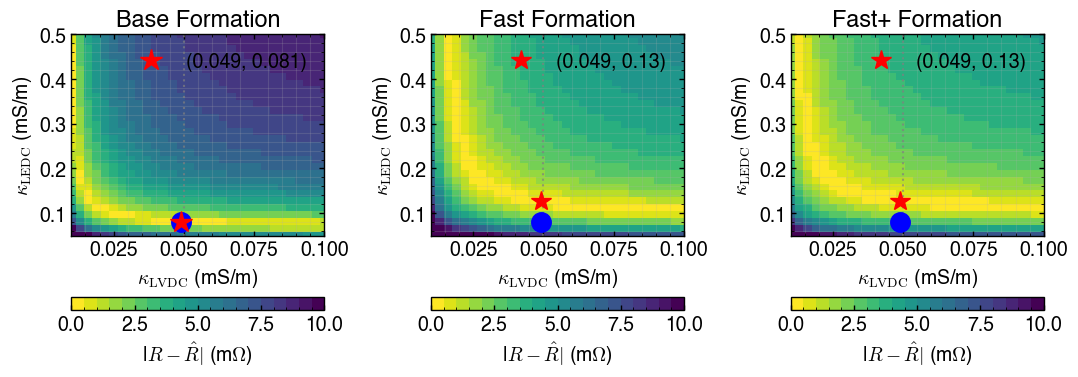

In [79]:
import pickle
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
# with open('outputs/simulation_results.pkl', 'rb') as f:
with open('outputs/resistance_optimization_results_20251202.pkl', 'rb') as f:
    sim_results = pickle.load(f)

nn = 30
kappa_ec_vec = np.linspace(5e-5, 5e-4, nn)
kappa_vc_vec = np.linspace(1e-5, 1e-4, nn+1)

# Extract variables from the loaded results
er1_mat = sim_results['rmse1_e_mat']*1e3
er2_mat = sim_results['rmse2_e_mat']*1e3
er3_mat = sim_results['rmse3_e_mat']*1e3

simutils.plot_heatmaps_kappa(kappa_ec_vec*1e3, kappa_vc_vec*1e3, er1_mat, er2_mat, er3_mat, 
                                   r'|$R - \hat{R}|$ (m$\Omega$)', zmin=0.000, zmax=10, tosave=True,  
                                   savename='outputs/figures/heatmap_resistance_error.svg')

# Extract optimal values for kappa EC and kappa VC based on the map

In [ ]:
target_kappa_vc = 3.10e-5
idx_vc = (np.abs(kappa_vc_vec - target_kappa_vc)).argmin()

idx_ec = np.argmin(er1_mat[:,idx_vc])
print(f'Base: Optimal (KEC|KVC): {kappa_ec_vec[idx_ec]:.3e} | {kappa_vc_vec[idx_vc]:.3e}')

idx_ec = np.argmin(er2_mat[:,idx_vc])
print(f'Fast: Optimal (KEC|KVC): {kappa_ec_vec[idx_ec]:.3e} | {kappa_vc_vec[idx_vc]:.3e}')

idx_ec = np.argmin(er3_mat[:,idx_vc])
print(f'Fast+: Optimal (KEC|KVC): {kappa_ec_vec[idx_ec]:.3e} | {kappa_vc_vec[idx_vc]:.3e}')

# Study some correlations

In [ ]:
# Create a table comparing SEI growth across different protocols
sim1_time1 = df_sim1['t'].iloc[-1]/3600
sim2_time1 = df_sim2['t'].iloc[-1]/3600
sim3_time1 = df_sim3['t'].iloc[-1]/3600

df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

# Study sensitivity of model error to choice of {rhosei1, rhosei2}

In [11]:
expt1, _ = ioutils.fetch_experimental_data(152064, 400)
# expt2 = fetch_experimental_data(152074)
expt3, _ = ioutils.fetch_experimental_data(152071, 400)
expt4, _ = ioutils.fetch_experimental_data(152098, 400)

In [88]:
# d_ec_opt1 = 3.857e-20
# d_vc_opt1 = 1.259e-16
# d_ec_opt2 = 3.857e-20
# d_vc_opt2 = 1.995e-18
# d_ec_opt3 = 5.736e-20
# d_vc_opt3 = 1.585e-17

# d_ec_opt1 = 3.857e-20
# d_vc_opt1 = 1.259e-16
# d_ec_opt2 = 3.857e-20
# d_vc_opt2 = 3.981e-18 #< different
# d_ec_opt3 = 5.736e-20
# d_vc_opt3 = 1.585e-17

# Tuning based on voltage
# d_ec_opt1 = 3.857e-20
# d_vc_opt1 = 1.585e-17
# d_ec_opt2 = 3.857e-20
# d_vc_opt2 = 1.259e-16
# d_ec_opt3 = 3.857e-20
# d_vc_opt3 = 3.162e-17

# Tuning based on voltage
d_ec_opt1 = 3.857e-20
d_vc_opt1 = 1.585e-17
d_ec_opt2 = 3.857e-20
d_vc_opt2 = 1.585e-17
d_ec_opt3 = 3.857e-20
d_vc_opt3 = 1.585e-17

nn = 30

rho_ec_vec = np.linspace(0.1, 4, nn)
rho_vc_vec = np.linspace(0.1, 4, nn+1)

rmse1_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse1_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse2_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse2_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse3_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse3_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei1_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei2_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei3_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

expan1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
expan2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
expan3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

resistance1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
resistance2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))   
resistance3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

count = 1

for i, rho_ec in enumerate(rho_ec_vec):
    for j, rho_vc in enumerate(rho_vc_vec):

        print(f'Running rho_EC = {rho_ec:.2e} | rho_VC = {rho_vc:.2e} ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=3)
            df_sim2 = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=3)
            df_sim3 = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=3)
        except:
            print('ERROR')
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'], y_range=(3.2, 4.2))
        rmse1_e, _, _ = simutils.calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'], y_range=(3.2, 4.2))
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'], y_range=(3.2, 4.2))
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running rho_EC = 1.00e-01 | rho_VC = 1.00e-01 (1 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 2.30e-01 (2 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 3.60e-01 (3 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 4.90e-01 (4 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 6.20e-01 (5 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 7.50e-01 (6 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 8.80e-01 (7 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.01e+00 (8 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.14e+00 (9 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.27e+00 (10 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.40e+00 (11 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.53e+00 (12 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.66e+00 (13 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.79e+00 (14 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.92e+00 (15 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 2.05e+00 (16 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 2.18e+00 (17 of 930)
Running rho_EC = 1.00e-

: 

In [25]:
variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
}

with open('outputs/simulation_results_density_20251202.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

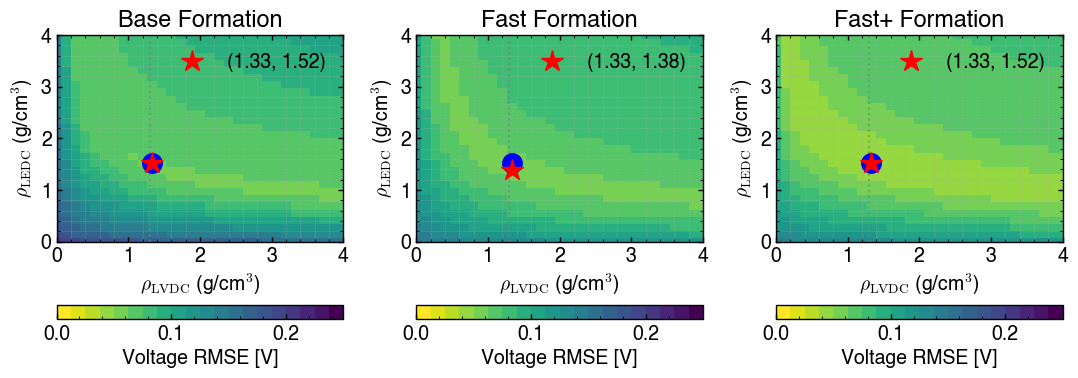

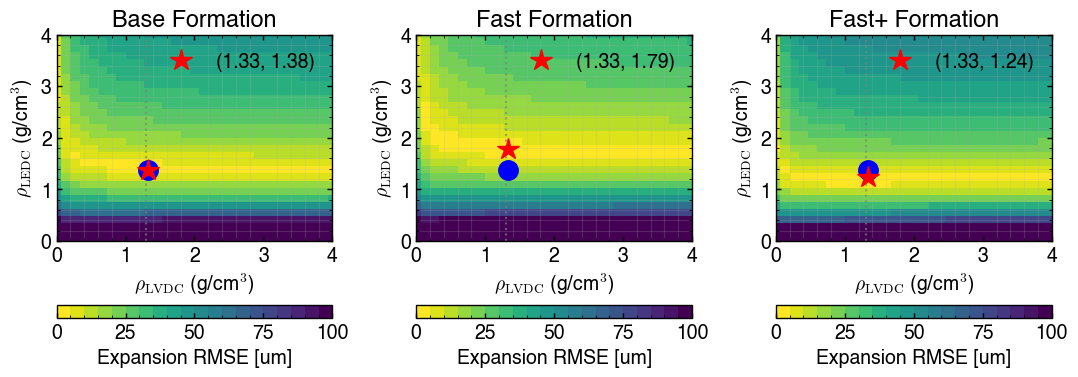

In [76]:
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
with open('outputs/simulation_results_density_20251202.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.linspace(0.0, 4.0, 30)
diff_vc_vec = np.linspace(0.0, 4.0, 31)

# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']
rmse1_v_mat = sim_results['rmse1_v_mat']
rmse2_e_mat = sim_results['rmse2_e_mat'] 
rmse2_v_mat = sim_results['rmse2_v_mat']
rmse3_e_mat = sim_results['rmse3_e_mat']
rmse3_v_mat = sim_results['rmse3_v_mat']
qsei1_mat = sim_results['qsei1_mat']
qsei2_mat = sim_results['qsei2_mat']
qsei3_mat = sim_results['qsei3_mat']
qsei1_vc_mat = sim_results['qsei1_vc_mat']
qsei2_vc_mat = sim_results['qsei2_vc_mat']
qsei3_vc_mat = sim_results['qsei3_vc_mat']
expan1_mat = sim_results['expan1_mat']
expan2_mat = sim_results['expan2_mat']
expan3_mat = sim_results['expan3_mat']
resistance1_mat = sim_results['resistance1_mat']
resistance2_mat = sim_results['resistance2_mat']
resistance3_mat = sim_results['resistance3_mat']
combined_rmse1 = sim_results['combined_rmse1']
combined_rmse2 = sim_results['combined_rmse2']
combined_rmse3 = sim_results['combined_rmse3']
eq1_mat = sim_results['eq1_mat']
eq2_mat = sim_results['eq2_mat']
eq3_mat = sim_results['eq3_mat']
er1_mat = sim_results['er1_mat'] 
er2_mat = sim_results['er2_mat']
er3_mat = sim_results['er3_mat']
ec1_mat = sim_results['ec1_mat']
ec2_mat = sim_results['ec2_mat']
ec3_mat = sim_results['ec3_mat']


simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, 'Voltage RMSE [V]', 
                                   zmin=0, zmax=0.25, tosave=True, savename='outputs/figures/heatmap_rho_rmse_v.svg')
simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 'Expansion RMSE [um]', 
                                   zmin=0, zmax=100, tosave=True, savename='outputs/figures/heatmap_rho_rmse_e.svg')

In [ ]:
# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.73
rho_ec_opt = 1.38

# Study sensitivity of model error to choice of {DSEI1, DSEI2}

## Simulate protocols

In [18]:
# Extend the dataset to include in the study
expt1, df1 = ioutils.fetch_experimental_data(152064, 400)
# expt2 = fetch_experimental_data(152074, 400)
expt3, df3 = ioutils.fetch_experimental_data(152071, 400)
expt4, df4 = ioutils.fetch_experimental_data(152098, 400)


dt_data_interp = 5.0
t_interp1, i_interp1 = simutils.interpolate_raw_data(expt1['arbin_time'], expt1['arbin_current'], dt_data_interp)
t_interp3, i_interp3 = simutils.interpolate_raw_data(expt3['arbin_time'], expt3['arbin_current'], dt_data_interp)
t_interp4, i_interp4 = simutils.interpolate_raw_data(expt4['arbin_time'], expt4['arbin_current'], dt_data_interp)


In [19]:
nn = 30

diff_ec_vec = np.logspace(-22, -17, nn)
diff_vc_vec = np.logspace(-21, -12, nn+1)

rmse1_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse1_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse2_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_e_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
rmse3_v_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei1_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei2_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
qsei3_vc_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

expan1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
expan3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

resistance1_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))
resistance2_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))   
resistance3_mat = np.zeros((len(diff_ec_vec), len(diff_vc_vec)))

count = 1

for i, diff_ec in enumerate(diff_ec_vec):
    for j, diff_vc in enumerate(diff_vc_vec):

        print(f'Running D_EC = {diff_ec:.2e} m2/s and D_VC = {diff_vc:.2e} m2/s ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', diff_ec, diff_vc, dt=1, include_flag=3)
            df_sim2 = simutils.run_sim('fast', diff_ec, diff_vc, dt=1, include_flag=3)
            df_sim3 = simutils.run_sim('fast+', diff_ec, diff_vc, dt=1, include_flag=3)
        except:
            print('ERROR')
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt1['arbin_time'], expt1['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
        rmse1_e, _, _ = simutils.calculate_rmse(expt1['daq_time'],   expt1['daq_strain'], df_sim1['t'], df_sim1['expansion']*1e6)
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain'], df_sim2['t'], df_sim2['expansion']*1e6)
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain'], df_sim3['t'], df_sim3['expansion']*1e6)

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running D_EC = 1.00e-22 m2/s and D_VC = 1.00e-21 m2/s (1 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.00e-21 m2/s (2 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.98e-21 m2/s (3 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 7.94e-21 m2/s (4 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.58e-20 m2/s (5 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.16e-20 m2/s (6 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 6.31e-20 m2/s (7 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.26e-19 m2/s (8 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.51e-19 m2/s (9 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 5.01e-19 m2/s (10 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.00e-18 m2/s (11 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.00e-18 m2/s (12 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.98e-18 m2/s (13 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 7.94e-18 m2/s (14 of 930)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.58e-17 m2/s (15 of 930)
Running D_EC = 1.00

# Create a scatterplot of expansion, capacity, and resistance, for all simulated combinations of {DSEI1, DSEI2}

In [ ]:
qsei1_flat = qsei1_mat.flatten()
qsei2_flat = qsei2_mat.flatten()
qsei3_flat = qsei3_mat.flatten()

expan1_flat = expan1_mat.flatten()
expan2_flat = expan2_mat.flatten()
expan3_flat = expan3_mat.flatten()

resistance1_flat = resistance1_mat.flatten()
resistance2_flat = resistance2_mat.flatten()
resistance3_flat = resistance3_mat.flatten()

plt.figure(figsize=(8, 6))
plt.scatter(qsei1_flat, expan1_flat*1e6, alpha=0.7, edgecolors='k', label='Base')
plt.scatter(qsei2_flat, expan2_flat*1e6, alpha=0.7, edgecolors='k', label='Fast')
plt.scatter(qsei3_flat, expan3_flat*1e6, alpha=0.7, edgecolors='k', label='Fast+')
plt.xlabel('Q_SEI (Ah)')
plt.ylabel('Expansion (um)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(qsei1_flat, resistance1_flat, alpha=0.7, edgecolors='k', label='Base')
plt.scatter(qsei2_flat, resistance2_flat, alpha=0.7, edgecolors='k', label='Fast')
plt.scatter(qsei3_flat, resistance3_flat, alpha=0.7, edgecolors='k', label='Fast+')
plt.xlabel('Q_SEI (Ah)')
plt.ylabel('Resistance (Ohms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.ylim((0, 0.2))
plt.show()

# Prepare data for plotting {DSEI, DSEI2} heatmaps

### Cache simulation outputs to disk

In [20]:
# Pickle all variables to a file to save the simulation results
import pickle

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
}

with open('outputs/simulation_results_20251130.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

### Read simulation outputs from disk

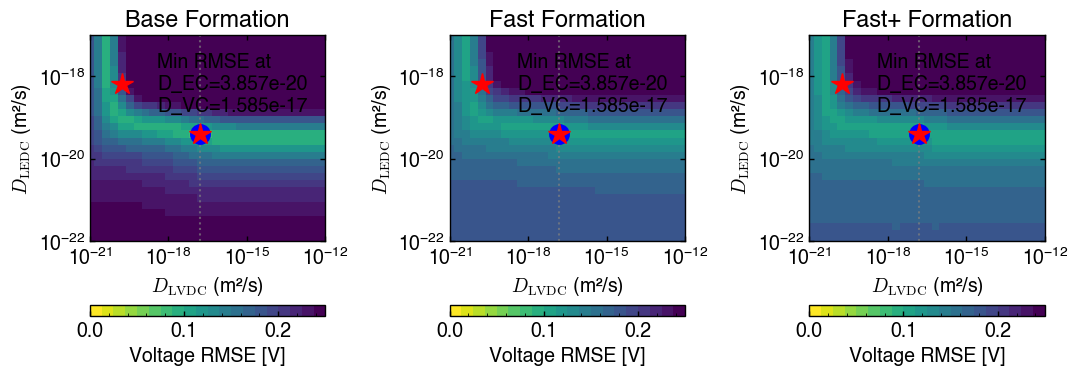

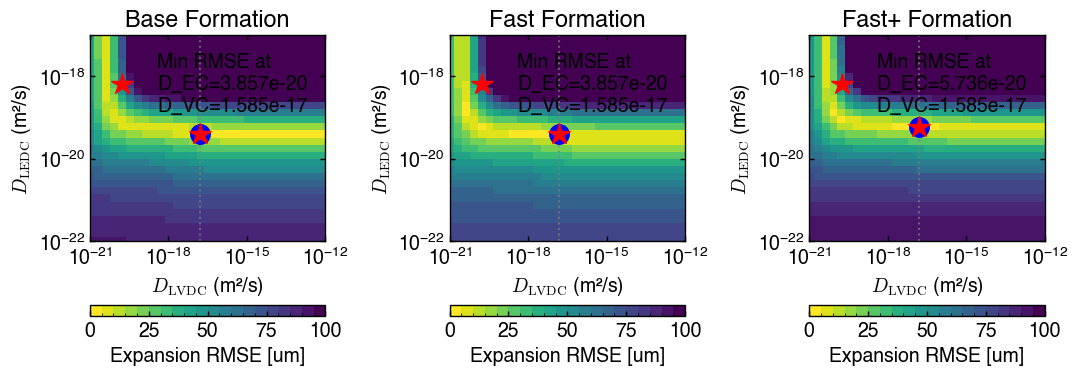

In [87]:
import pickle
%autoreload 2

%matplotlib inline
with open('outputs/simulation_results_20251130.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.logspace(-22, -17, 30)
diff_vc_vec = np.logspace(-21, -12, 31)


# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']
rmse1_v_mat = sim_results['rmse1_v_mat']
rmse2_e_mat = sim_results['rmse2_e_mat'] 
rmse2_v_mat = sim_results['rmse2_v_mat']
rmse3_e_mat = sim_results['rmse3_e_mat']
rmse3_v_mat = sim_results['rmse3_v_mat']
qsei1_mat = sim_results['qsei1_mat']
qsei2_mat = sim_results['qsei2_mat']
qsei3_mat = sim_results['qsei3_mat']
qsei1_vc_mat = sim_results['qsei1_vc_mat']
qsei2_vc_mat = sim_results['qsei2_vc_mat']
qsei3_vc_mat = sim_results['qsei3_vc_mat']
expan1_mat = sim_results['expan1_mat']
expan2_mat = sim_results['expan2_mat']
expan3_mat = sim_results['expan3_mat']
resistance1_mat = sim_results['resistance1_mat']
resistance2_mat = sim_results['resistance2_mat']
resistance3_mat = sim_results['resistance3_mat']
combined_rmse1 = sim_results['combined_rmse1']
combined_rmse2 = sim_results['combined_rmse2']
combined_rmse3 = sim_results['combined_rmse3']
eq1_mat = sim_results['eq1_mat']
eq2_mat = sim_results['eq2_mat']
eq3_mat = sim_results['eq3_mat']
er1_mat = sim_results['er1_mat'] 
er2_mat = sim_results['er2_mat']
er3_mat = sim_results['er3_mat']
ec1_mat = sim_results['ec1_mat']
ec2_mat = sim_results['ec2_mat']
ec3_mat = sim_results['ec3_mat']



simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, 'Voltage RMSE [V]', 
                                   zmin=0, zmax=0.25, tosave=True, savename='outputs/figures/heatmap_diff_rmse_v.svg') 
simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 'Expansion RMSE [um]', 
                                   zmin=0, zmax=100, tosave=True, savename='outputs/figures/heatmap_diff_rmse_e.svg')

# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, eq1_mat, eq2_mat, eq3_mat, '$E_Q = (Q-\hat{Q})^2$', zmin=0, zmax=0.2, tosave=True, savename='heatmap_eq.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, er1_mat, er2_mat, er3_mat, '$E_R = (R-\hat{R})^2$', zmin=0, zmax=0.01, tosave=True, savename='heatmap_er.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, ec1_mat, ec2_mat, ec3_mat, '$E_Q + E_R$', zmin=0.0, zmax=0.05, tosave=True, savename='heatmap_ec.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, combined_rmse1, combined_rmse2, combined_rmse3, '$RMSE_V + RMSE_{\epsilon}$', zmin=0.00, zmax=0.5, tosave=True, savename='heatmap_combined_rmse.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat, '$Q_{VC}$', is_error_plot=False, tosave=True, savename='heatmap_qsei_vc.svg')

In [ ]:
# Tuning based on voltage
d_ec_opt1 = 3.857e-20
d_vc_opt1 = 1.585e-17
d_ec_opt2 = 3.857e-20
d_vc_opt2 = 1.585e-17
d_ec_opt3 = 3.857e-20
d_vc_opt3 = 1.585e-17

# Tuning based on expansion
d_ec_opt1 = 3.857e-20
d_vc_opt1 = 1.259e-16
d_ec_opt2 = 3.857e-20
d_vc_opt2 = 3.981e-18
d_ec_opt3 = 5.736e-20
d_vc_opt3 = 1.585e-17

In [ ]:
er1_mat.shape

In [ ]:
target_diff_vc = 3.162e-17
index = (np.abs(diff_vc_vec - target_diff_vc)).argmin()
rmse1_e_slice = rmse1_e_mat[:, index]
rmse2_e_slice = rmse2_e_mat[:, index]
rmse3_e_slice = rmse3_e_mat[:, index]
rmse1_v_slice = rmse1_v_mat[:, index]
rmse2_v_slice = rmse2_v_mat[:, index]
rmse3_v_slice = rmse3_v_mat[:, index]

target_kappa_vc = 3.10e-5
index = (np.abs(kappa_vc_vec - target_kappa_vc)).argmin()
er1_slice = er1_mat[:, index]
er2_slice = er2_mat[:, index]
er3_slice = er3_mat[:, index]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

# Voltage Error
axes[0].set_xscale('log')
axes[0].plot(diff_ec_vec, rmse1_v_slice, marker='o', linestyle='-', color='b', label='Base')
axes[0].plot(diff_ec_vec, rmse2_v_slice, marker='o', linestyle='-', color='g', label='Fast')
axes[0].plot(diff_ec_vec, rmse3_v_slice, marker='o', linestyle='-', color='r', label='Fast+')
axes[0].text(0.05, 0.95, f'$D_{{\\mathrm{{LVDC}}}}$ = {diff_vc_vec[index]:.2e} m$^2$/s', 
             transform=axes[0].transAxes, fontsize=13, color='k', verticalalignment='top',
             bbox=dict(facecolor='white', edgecolor='none'))
axes[0].set_ylabel('Voltage RMSE (V)')
axes[0].set_xlabel('$D_{\mathrm{LEDC}}$ (m²/s)')
axes[0].set_ylim((0, 0.250))
axes[0].set_xlim((1e-21, 1e-18))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

# Expansion error
axes[1].set_xscale('log')
axes[1].plot(diff_ec_vec, rmse1_e_slice, marker='o', linestyle='-', color='b', label='Base')
axes[1].plot(diff_ec_vec, rmse2_e_slice, marker='o', linestyle='-', color='g', label='Fast')
axes[1].plot(diff_ec_vec, rmse3_e_slice, marker='o', linestyle='-', color='r', label='Fast+')
axes[1].set_xlabel('$D_{\mathrm{LEDC}}$ (m²/s)')
axes[1].set_ylabel('Expansion RMSE (µm)')
axes[1].set_ylim((0, 100))
axes[1].set_xlim((1e-21, 1e-18))
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].text(0.05, 0.95, f'$D_{{\\mathrm{{LVDC}}}}$ = {diff_vc_vec[index]:.2e} m$^2$/s', 
             transform=axes[1].transAxes, fontsize=13, color='k', verticalalignment='top',
             bbox=dict(facecolor='white', edgecolor='none'))
axes[1].legend(loc='lower right')

# Resistance error
axes[2].plot(kappa_ec_vec*1e3, er1_slice, marker='o', linestyle='-', color='b', label='Base')
axes[2].plot(kappa_ec_vec*1e3, er2_slice, marker='o', linestyle='-', color='g', label='Fast')
axes[2].plot(kappa_ec_vec*1e3, er3_slice, marker='o', linestyle='-', color='r', label='Fast+')
axes[2].set_xlabel('$\kappa_{\mathrm{LEDC}}$ (mS/m)')
axes[2].set_ylabel('Resistance Error (m$\Omega$)')
axes[2].set_ylim((0, 10))
# axes[2].set_xlim((0.1, 0.3))
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].text(0.05, 0.95, f'$\kappa_{{\\mathrm{{LVDC}}}}$ = {kappa_vc_vec[index]*1e3:.2e} mS/m', 
             transform=axes[2].transAxes, fontsize=13, color='k', verticalalignment='top',
             bbox=dict(facecolor='white', edgecolor='none'))
axes[2].legend(loc='upper right', facecolor='white', framealpha=0)

plt.tight_layout()
plt.show()

# Save the plot as an SVG file
fig.savefig('outputs/figures/rmse_vs_diff_ec.svg', format='svg')